## Physics Informed Neural Networks to Approximate Solution of PDEs

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import sys
sys.path.append('/content/drive/My Drive/Colab Notebooks')


In [14]:
!pip install wandb -qU

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.3/184.3 kB 13.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.7/206.7 kB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 1.8 MB/s eta 0:00:00


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import torch
from torch.utils.data import DataLoader
from Common import NeuralNet, MultiVariatePoly
import time
torch.autograd.set_detect_anomaly(True)
torch.manual_seed(128)
import pandas as pd
import wandb
from random import SystemRandom

In [16]:
wandb.login()

<IPython.core.display.Javascript object>

wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [17]:
wandb.login()

wandb: Currently logged in as: bananabond. Use `wandb login --relogin` to force relogin


True

In [25]:
class Pinns:
    def __init__(self, n_int_, n_sb_, n_tb_):
        self.n_int = n_int_
        self.n_sb = n_sb_
        self.n_tb = n_tb_

        # Extrema of the solution domain (t,x) in [0,0.1]x[-1,1]
        self.domain_extrema = torch.tensor([[0, 8],  # Time dimension
                                            [0, 1]])  # Space dimension

        # Number of space dimensions
        self.space_dimensions = 1

        # Parameter to balance role of data and PDE
        self.lambda_u = 10

        # F Dense NN to approximate the solution of the underlying heat equation - OP = [Ts, Tf]
        self.approximate_solution = NeuralNet(input_dimension=self.domain_extrema.shape[0], output_dimension=2,
                                              n_hidden_layers=4,
                                              neurons=25,
                                              regularization_param=0.,
                                              regularization_exp=2.,
                                              retrain_seed=42)
        '''self.approximate_solution = MultiVariatePoly(self.domain_extrema.shape[0], 3)'''

        # Generator of Sobol sequences
        self.soboleng = torch.quasirandom.SobolEngine(dimension=self.domain_extrema.shape[0])

        # Training sets S_sb, S_tb, S_int as torch dataloader
        self.training_set_sb_Tf_charging, self.training_set_sb_Tf_discharging, self.training_set_sb_Tf_idle, self.training_set_tb, self.training_set_int, self.training_set_meas = self.assemble_datasets()

    ################################################################################################
    # Function to linearly transform a tensor whose value are between 0 and 1
    # to a tensor whose values are between the domain extrema
    def convert(self, tens):
        assert (tens.shape[1] == self.domain_extrema.shape[0])
        return tens * (self.domain_extrema[:, 1] - self.domain_extrema[:, 0]) + self.domain_extrema[:, 0]

    # Initial condition to solve the heat equation u0(x)=-sin(pi x)
    def initial_condition(self, x):
        return torch.ones(x.shape)

    # Exact solution for the heat equation ut = u_xx with the IC above
    def exact_solution(self, inputs):
        t = inputs[:, 0]
        x = inputs[:, 1]

        u = -torch.exp(-np.pi ** 2 * t) * torch.sin(np.pi * x)
        return u

    ################################################################################################
    # Function returning the input-output tensor required to assemble the training set S_tb corresponding to the temporal boundary
    def add_temporal_boundary_points(self):
        t0 = self.domain_extrema[0, 0]
        input_tb = self.convert(self.soboleng.draw(self.n_tb))
        input_tb[:, 0] = torch.full(input_tb[:, 0].shape, t0)
        output_tb_Tf = self.initial_condition(input_tb[:, 1]).reshape(-1, 1)
        # output_tb_Tf = self.initial_condition(input_tb[:, 1]).reshape(-1, 1)
        return input_tb, output_tb_Tf
    # Function returning the input-output tensor required to assemble the training set S_sb corresponding to the spatial boundary

    def get_measurement_data(self):
        path_to_file = r"/content/drive/My Drive/Colab Notebooks/DataSolution.txt"
        train = pd.read_csv(path_to_file, dtype= np.float64)
        train_tensor = torch.tensor(train.values, dtype = torch.float32)
        # input_meas = torch.ones((train_tensor.shape[0]),2)
        # output_meas = torch.ones(((train_tensor.shape[0]),1))
        # for i, item in enumerate(train_tensor):
        #     input_meas[i] = torch.tensor([(train_tensor[i][0]), (train_tensor[i][1])])
        #     output_meas[i] = torch.tensor((train_tensor[i][2]))
        input_meas = train_tensor[:,:2]
        output_meas = train_tensor[:,-1]
        return input_meas, output_meas

    def add_spatial_boundary_points(self):
        x0 = self.domain_extrema[1, 0]
        xL = self.domain_extrema[1, 1]

        input_sb = self.convert(self.soboleng.draw(self.n_sb))

        input_sb_0 = torch.clone(input_sb)
        input_sb_0[:, 1] = torch.full(input_sb_0[:, 1].shape, x0)
        input_sb_0_charging = torch.stack(list(filter(lambda c: (float(c[0]) >= 0.0 and float(c[0]) < 1.0) or float(c[0]) >= 4.0 and float(c[0]) < 5.0, input_sb_0)))
        input_sb_0_discharging = torch.stack(list(filter(lambda c: (float(c[0]) >= 2.0 and float(c[0]) < 3.0) or float(c[0]) >= 6.0 and float(c[0]) < 7.0, input_sb_0)))
        input_sb_0_idle= torch.stack(list(filter(lambda c: (float(c[0]) >= 1.0 and float(c[0]) < 2.0) or (float(c[0]) >= 3.0 and float(c[0]) < 4.0) or (float(c[0]) >= 5.0 and float(c[0]) < 6.0) or (float(c[0]) >= 7.0 and float(c[0]) <= 8.0) , input_sb_0)))
        # input_sb_0_idle_2 = torch.stack(list(filter(lambda c: (float(c[0]) >= 5.0 and float(c[0]) < 6.0) or (float(c[0]) >= 7.0 and float(c[0]) <= 8.0) , input_sb_0)))


        input_sb_L = torch.clone(input_sb)
        input_sb_L[:, 1] = torch.full(input_sb_L[:, 1].shape, xL)
        input_sb_L_discharging = torch.stack(list(filter(lambda c: (float(c[0]) >= 2.0 and float(c[0]) < 3.0) or float(c[0]) >= 6.0 and float(c[0]) < 7.0, input_sb_L)))
        input_sb_L_charging = torch.stack(list(filter(lambda c: (float(c[0]) >= 0.0 and float(c[0]) < 1.0) or float(c[0]) >= 4.0 and float(c[0]) < 5.0, input_sb_L)))
        input_sb_L_idle = torch.stack(list(filter(lambda c: (float(c[0]) >= 1.0 and float(c[0]) < 2.0) or (float(c[0]) >= 3.0 and float(c[0]) < 4.0) or (float(c[0]) >= 5.0 and float(c[0]) < 6.0) or (float(c[0]) >= 7.0 and float(c[0]) <= 8.0) , input_sb_L)))
        # input_sb_L_idle_2 = torch.stack(list(filter(lambda c: (float(c[0]) >= 5.0 and float(c[0]) < 6.0) or (float(c[0]) >= 7.0 and float(c[0]) <= 8.0) , input_sb_L)))
        input_sb_charging = torch.cat([input_sb_0_charging, input_sb_L_charging], 0)
        input_sb_discharging = torch.cat([input_sb_0_discharging, input_sb_L_discharging], 0)
        input_sb_idle = torch.cat([input_sb_0_idle, input_sb_L_idle], 0)


        output_sb_Tf_0_charging = torch.full(input_sb_0_charging[:, 1].shape, 4)  # Thot = 4
        output_sb_Tf_L_charging = torch.zeros(input_sb_L_charging[:, 1].shape)
        output_sb_Tf_charging = torch.cat([output_sb_Tf_0_charging, output_sb_Tf_L_charging],0)

        output_sb_Tf_L_discharging = torch.full(input_sb_L_discharging[:, 1].shape, 1) # Tcold = 1
        output_sb_Tf_0_discharging = torch.zeros(input_sb_L_discharging[:, 1].shape)
        output_sb_Tf_discharging = torch.cat([output_sb_Tf_0_discharging, output_sb_Tf_L_discharging], 0)
        output_sb_Tf_idle = torch.zeros(input_sb_idle.shape)

        return input_sb_charging, output_sb_Tf_charging, input_sb_discharging, output_sb_Tf_discharging, input_sb_idle, output_sb_Tf_idle


    #  Function returning the input-output tensor required to assemble the training set S_int corresponding to the interior domain where the PDE is enforced
    def add_interior_points(self):
        input_int = self.convert(self.soboleng.draw(self.n_int))
        output_int = torch.zeros((input_int.shape[0], 1))
        # output_int_Tf = torch.zeros((input_int.shape[0], 1))
        return input_int, output_int

    # Function returning the training sets S_sb, S_tb, S_int as dataloader
    def assemble_datasets(self):
        input_sb_charging, output_sb_Tf_charging, input_sb_discharging, output_sb_Tf_discharging, input_sb_idle, output_sb_Tf_idle  = self.add_spatial_boundary_points()   # S_sb
        input_tb, output_tb = self.add_temporal_boundary_points()  # S_tb
        input_int, output_int = self.add_interior_points()         # S_int
        input_meas, output_meas = self.get_measurement_data()
        training_set_sb_Tf_charging = DataLoader(torch.utils.data.TensorDataset(input_sb_charging, output_sb_Tf_charging), batch_size=2*self.space_dimensions*self.n_sb, shuffle=False)
        training_set_sb_Tf_discharging = DataLoader(torch.utils.data.TensorDataset(input_sb_discharging, output_sb_Tf_discharging), batch_size=2*self.space_dimensions*self.n_sb, shuffle=False)
        training_set_sb_Tf_idle = DataLoader(torch.utils.data.TensorDataset(input_sb_idle, output_sb_Tf_idle), batch_size=4*self.space_dimensions*self.n_sb, shuffle=False)
        training_set_tb = DataLoader(torch.utils.data.TensorDataset(input_tb, output_tb), batch_size=self.n_tb, shuffle=False)
        training_set_int = DataLoader(torch.utils.data.TensorDataset(input_int, output_int), batch_size=self.n_int, shuffle=False)
        training_set_meas = DataLoader(torch.utils.data.TensorDataset(input_meas, output_meas), batch_size=8*self.n_int, shuffle=True)

        return  training_set_sb_Tf_charging, training_set_sb_Tf_discharging, training_set_sb_Tf_idle, training_set_tb, training_set_int, training_set_meas

    ################################################################################################
    # Function to compute the terms required in the definition of the TEMPORAL boundary residual
    def apply_initial_condition(self, input_tb):
        u_pred_tb = self.approximate_solution(input_tb)
        return u_pred_tb

    # Function to compute the terms required in the definition of the SPATIAL boundary residual
    def apply_boundary_conditions(self, input_sb):
        u_pred_sb = self.approximate_solution(input_sb)

        return u_pred_sb

    # Function to compute the PDE residuals
    def compute_pde_residual(self, input_int):
        input_int.requires_grad = True
        u = self.approximate_solution(input_int)
        Ts = u[:,0]
        Tf = u[:,1]
        # grad compute the gradient of a "SCALAR" function L with respect to some input nxm TENSOR Z=[[x1, y1],[x2,y2],[x3,y3],...,[xn,yn]], m=2
        # it returns grad_L = [[dL/dx1, dL/dy1],[dL/dx2, dL/dy2],[dL/dx3, dL/dy3],...,[dL/dxn, dL/dyn]]
        # Note: pytorch considers a tensor [u1, u2,u3, ... ,un] a vectorial function
        # whereas sum_u = u1 + u2 + u3 + u4 + ... + un as a "scalar" one

        # In our case ui = u(xi), therefore the line below returns:
        # grad_u = [[dsum_u/dx1, dsum_u/dy1],[dsum_u/dx2, dsum_u/dy2],[dsum_u/dx3, dL/dy3],...,[dsum_u/dxm, dsum_u/dyn]]
        # and dsum_u/dxi = d(u1 + u2 + u3 + u4 + ... + un)/dxi = d(u(x1) + u(x2) u3(x3) + u4(x4) + ... + u(xn))/dxi = dui/dxi
        grad_Ts = torch.autograd.grad(Ts.sum(), input_int, create_graph=True)[0]
        grad_Ts_t = grad_Ts[:, 0]
        grad_Ts_x = grad_Ts[:, 1]
        grad_Ts_xx = torch.autograd.grad(grad_Ts_x.sum(), input_int, create_graph=True)[0][:, 1]

        # grad_u_sq_x = torch.autograd.grad(u_sq.sum(), input_int, create_graph=True)[0][:,1]

        grad_Tf = torch.autograd.grad(u.sum(), input_int, create_graph=True)[0]
        grad_Tf_t = grad_Tf[:, 0]
        grad_Tf_x = grad_Tf[:, 1]
        grad_Tf_xx = torch.autograd.grad(grad_Tf_x.sum(), input_int, create_graph=True)[0][:, 1]


        # U_f
        U_f = torch.full(input_int[:,0].shape, 1)
        for i, _ in enumerate(input_int):
            if (input_int[i][0] >= 1 and input_int[i][0] < 2) or (input_int[i][0] >= 3 and input_int[i][0] < 4) or (input_int[i][0] >= 5 and input_int[i][0] < 6) or (input_int[i][0] >= 7 and input_int[i][0] <= 8):
                    U_f[i] = 0
            elif (input_int[i][0] >= 2 and input_int[i][0] < 3) or (input_int[i][0] >= 6 and input_int[i][0] < 7):
                    U_f[i] = -1
            elif (input_int[i][0] >= 0 and input_int[i][0] < 1) or (input_int[i][0] >= 4 and input_int[i][0] < 5):
                    U_f[i] = 1


        residual = (grad_Tf_t) + (U_f * grad_Tf_x) - 0.005 * (grad_Tf_xx) + 5 * (Tf - Ts)

        return residual.reshape(-1, )

    # Function to compute the total loss (weighted sum of spatial boundary loss, temporal boundary loss and interior loss)

    def compute_loss(self, inp_train_sb_charging, u_train_sb_Tf_charging, inp_train_sb_discharging, u_train_sb_Tf_discharging, inp_train_sb_idle, u_train_sb_Tf_idle , inp_train_tb, u_train_tb, inp_train_int , inp_train_meas, u_train_meas, verbose=True):
        inp_train_sb_charging.requires_grad = True
        inp_train_sb_discharging.requires_grad = True
        inp_train_sb_idle.requires_grad = True
        # print(" inside compu_loss u_train_sb_Tf_0 = " + str(u_train_sb_Tf_0.shape))
        u_pred_sb_charging_Tf = self.apply_boundary_conditions(inp_train_sb_charging)[:, 1]
        u_pred_sb_discharging_Tf = self.apply_boundary_conditions(inp_train_sb_discharging)[:, 1]
        u_pred_sb_idle_Tf = self.apply_boundary_conditions(inp_train_sb_idle)[:, 1]
        # print('comp loss u_pred_sb_0 = ' + str(u_pred_sb_0.shape))
        # u_pred_sb_charging_Tf = u_pred_sb_charging[:, 1]
        # u_pred_sb_discharging_Tf = u_pred_sb_discharging[:, 1]
        # u_pred_sb_idle_Tf = u_pred_sb_idle[:, 1]
        sb_half_cd = int(inp_train_sb_charging.shape[0]/2)

        # print(type(sb_half))

        inp_train_meas, u_train_meas = self.get_measurement_data()

        grad_u_pred_sb_Tf_charging = torch.autograd.grad(u_pred_sb_charging_Tf.sum(), inp_train_sb_charging, create_graph=True)[0]
        grad_u_pred_sb_Tf_discharging = torch.autograd.grad(u_pred_sb_discharging_Tf.sum(), inp_train_sb_discharging, create_graph=True)[0]
        grad_u_pred_sb_Tf_idle = torch.autograd.grad(u_pred_sb_idle_Tf.sum(), inp_train_sb_idle, create_graph=True)[0]

        u_pred_tb = self.apply_initial_condition(inp_train_tb)
        u_pred_tb_Tf = u_pred_tb[:,1]

        # assert (u_pred_tb_Ts.shape[1] == u_train_tb_Ts.shape[1])
        # assert (u_pred_tb_Tf.shape[1] == u_train_tb_Tf.shape[1])

        u_pred_meas = self.approximate_solution(inp_train_meas)
        u_pred_meas_Tf = u_pred_meas[:,1]


        r_meas = u_pred_meas_Tf - u_train_meas
        # print('r_meas = ' + str(r_meas.shape))# r_meas = torch.Size([39200])
        # print('u_pred_meas_Tf = ' + str(u_pred_meas_Tf.shape))# u_pred_meas_Tf = torch.Size([39200])
        # print('u_train_meas = ' + str(u_train_meas.shape))# u_train_meas = torch.Size([39200])
        r_int = self.compute_pde_residual(inp_train_int)
        # print('r_int = ' + str(r_int.shape)) # r_int = torch.Size([2048])
        # print('u_pred_sb_charging_Tf = ' + str(u_pred_sb_charging_Tf.shape)) # u_pred_sb_charging_Tf = torch.Size([256])
        # print('u_train_sb_Tf_charging = ' + str(u_train_sb_Tf_charging.shape)) # u_train_sb_Tf_charging = torch.Size([256])
        r_sb_Tf_c_0 =  (u_pred_sb_charging_Tf[:sb_half_cd] - u_train_sb_Tf_charging[:sb_half_cd])
        r_sb_Tf_c_L = (grad_u_pred_sb_Tf_charging[sb_half_cd :, 1])
        r_sb_Tf_d_L =  (u_pred_sb_discharging_Tf[sb_half_cd:] - u_train_sb_Tf_discharging[sb_half_cd:])
        r_sb_Tf_d_0 = (grad_u_pred_sb_Tf_discharging[:sb_half_cd , 1])
        r_sb_Tf_i = (grad_u_pred_sb_Tf_idle[:, 1])
        # print('r_sb_Tf_c_0 = ' + str(r_sb_Tf_c_0.shape))# r_sb_Tf_c_0 = torch.Size([128])
        # print('r_sb_Tf_c_L = ' + str(r_sb_Tf_c_L.shape))# r_sb_Tf_c_L = torch.Size([128])
        # print('r_sb_Tf_d_L = ' + str(r_sb_Tf_d_L.shape))# r_sb_Tf_d_L = torch.Size([128])
        # print('r_sb_Tf_d_0 = ' + str(r_sb_Tf_d_0.shape)) # r_sb_Tf_d_0 = torch.Size([128])
        # print('r_sb_Tf_i = ' + str(r_sb_Tf_i.shape))# r_sb_Tf_i = torch.Size([512])
        r_sb_1 =  torch.cat([ r_sb_Tf_c_0,r_sb_Tf_d_L ], 0)
        r_sb_2 =  torch.cat([ r_sb_Tf_c_L, r_sb_Tf_d_0, r_sb_Tf_i], 0)


        # print('r_sb_1 = ' + str(r_sb_1.shape))# r_sb_1 = torch.Size([256])
        # print('r_sb_2 = ' + str(r_sb_2.shape))# r_sb_2 = torch.Size([768])
        # print('u_pred_sb_Tf = ' + str(u_pred_sb_Tf.shape))

        # print('r_tb_Ts = ' + str(r_tb_Ts.shape))
        # print('u_train_tb_Ts = ' + str(u_train_tb_Ts.shape))
        # print('u_pred_tb_Ts = ' + str(u_pred_tb_Ts.shape))
        r_tb = (u_train_tb[:,0] - u_pred_tb_Tf)
        # print('u_train_tb = ' + str(u_train_tb.shape))# u_train_tb = torch.Size([512, 1])
        # print('u_pred_tb_Tf = ' + str(u_pred_tb_Tf.shape))# u_pred_tb_Tf = torch.Size([512])
        # print('r_tb = ' + str(r_tb.shape))# r_tb = torch.Size([512])

        loss_sb_1 = torch.mean(abs(r_sb_1) ** 2)
        loss_sb_2 = torch.mean(abs(r_sb_2) ** 2)
        loss_tb = torch.mean(abs(r_tb) ** 2)
        loss_int = torch.mean(abs(r_int) ** 2)
        loss_meas = torch.mean(abs(r_meas) ** 2)
        loss_sb = loss_sb_1 + loss_sb_2
        loss_u = loss_sb + loss_tb + loss_meas

        loss = torch.log10(self.lambda_u * (loss_u) + loss_int)
        if verbose: print("Total loss: ", round(loss.item(), 4), "| PDE Loss: ", round(torch.log10(loss_u).item(), 4), "| Function Loss: ", round(torch.log10(loss_int).item(), 4))

        return loss, loss_u, loss_int

    ################################################################################################
    def fit(self, num_epochs, optimizer, verbose=True):
        history = list()

        # Loop over epochs
        for epoch in range(num_epochs):
            if verbose: print("################################ ", epoch, " ################################")

            for j, ((inp_train_sb_charging, u_train_sb_Tf_charging), (inp_train_sb_discharging, u_train_sb_Tf_discharging),(inp_train_sb_idle, u_train_sb_Tf_idle) , (inp_train_tb, u_train_tb), (inp_train_int, u_train_int) , (inp_train_meas, u_train_meas)) in enumerate(zip(self.training_set_sb_Tf_charging, self.training_set_sb_Tf_discharging, self.training_set_sb_Tf_idle, self.training_set_tb, self.training_set_int, self.training_set_meas)):
                def closure():
                    optimizer.zero_grad()
                    # print(" inside train u_train_sb_Tf = " + str(u_train_sb_Tf.shape))
                    loss, loss_u, loss_int = self.compute_loss(inp_train_sb_charging, u_train_sb_Tf_charging, inp_train_sb_discharging, u_train_sb_Tf_discharging,inp_train_sb_idle, u_train_sb_Tf_idle , inp_train_tb, u_train_tb, inp_train_int , inp_train_meas, u_train_meas, verbose=verbose)
                    loss.backward()
                    wandb.log({ 'loss' : round(loss.item(), 4), 'loss_u' : round(loss_u.item(), 4), 'loss_int' : round(loss_int.item(), 4)})
                    history.append(loss.item())
                    return loss

                optimizer.step(closure=closure)

        print('Final Loss: ', history[-1])

        return history

    ################################################################################################
    def plotting(self):
        inputs = self.soboleng.draw(100000)
        inputs = self.convert(inputs)

        output = self.approximate_solution(inputs)
        print('output.shape = ' + str(output.shape))
        output_Ts = (output[:,0]).reshape(-1, )
        output_Tf = (output[:,1]).reshape(-1, )
        # exact_output = self.exact_solution(inputs).reshape(-1, )

        fig, axs = plt.subplots(1, 2, figsize=(16, 8), dpi=150)
        im1 = axs[0].scatter(inputs[:, 1].detach(), inputs[:, 0].detach(), c=output_Tf.detach(), cmap="jet")
        axs[0].set_xlabel("x")
        axs[0].set_ylabel("t")
        plt.colorbar(im1, ax=axs[0])
        axs[0].grid(True, which="both", ls=":")
        im2 = axs[1].scatter(inputs[:, 1].detach(), inputs[:, 0].detach(), c=output_Ts.detach(), cmap="jet")
        axs[1].set_xlabel("x")
        axs[1].set_ylabel("t")
        plt.colorbar(im2, ax=axs[1])
        axs[1].grid(True, which="both", ls=":")
        axs[0].set_title("Approximate Solution - Tf")
        axs[1].set_title("Approximate Solution - Ts")

        plt.show()

        # err = (torch.mean((output - exact_output) ** 2) / torch.mean(exact_output ** 2)) ** 0.5 * 100
        # print("L2 Relative Error Norm: ", err.item(), "%")
    def plottingcheck(self):
        inputs = self.soboleng.draw(100000)
        inputs = self.convert(inputs)
        inputs0 = torch.clone(inputs)
        inputs0[:,1] = torch.full(inputs0[:,1].shape, 0)
        inputs05 = torch.clone(inputs)
        inputs05[:,1] = torch.full(inputs05[:,1].shape, 0.5)
        inputs1 = torch.clone(inputs)
        inputs1[:,1] = torch.full(inputs1[:,1].shape, 1)

        outputTf0 = self.approximate_solution(inputs0)[:,0].reshape(-1, )
        outputTs0 = self.approximate_solution(inputs0)[:,1].reshape(-1, )
        outputTf05 = self.approximate_solution(inputs05)[:,0].reshape(-1, )
        outputTs05 = self.approximate_solution(inputs05)[:,1].reshape(-1, )
        outputTf1 = self.approximate_solution(inputs1)[:,0].reshape(-1, )
        outputTs1 = self.approximate_solution(inputs1)[:,1].reshape(-1, )

        plt.figure(figsize=(16, 8), dpi=150)
        plt.scatter(inputs0[:, 0].detach(), outputTf0.detach(),  label= 'Tf0')
        plt.scatter(inputs05[:, 0].detach(), outputTf05.detach(), label= 'Tf05')
        plt.scatter(inputs1[:, 0].detach(), outputTf1.detach(), label= 'outputTf1')
        plt.scatter(inputs0[:, 0].detach(), outputTs0.detach(), label= 'outputTs0')
        plt.scatter(inputs05[:, 0].detach(), outputTs05.detach(), label= 'outputTs05')
        plt.scatter(inputs1[:, 0].detach(), outputTs1.detach(), label= 'outputTs1')
        plt.xlabel("t")
        plt.ylabel("T")
        plt.legend()
        plt.show()

In [26]:
# Solve the heat equation:
# u_t = u_xx, (t,x) in [0, 0.1]x[-1,1]
# with zero dirichlet BC and
# u(x,0)= -sin(pi x)

n_int = 1024
n_sb = 512
n_tb = 512

pinn = Pinns(n_int, n_sb, n_tb)

In [34]:
wandb_config = {}
experimentID = int(SystemRandom().random()*100000)
wandb_config.update({'n_tb' : n_tb, 'n_sb' : n_sb, 'n_int' : n_int })
# start a new wandb run to track this script
wandb.init(
    # set the wandb project where this run will be logged
    project="Task2-DLSC",
    name =  "Adam_25neurons_Colab_" + str(n_int) + "_" + str(n_sb) + "_" +  str(experimentID) ,
    # track hyperparameters and run metadata
    config=wandb_config
)

loss,██▇▇▆▅▅▄▄▃▃▂▁▁
loss_int,█▇▇▇▇▇▆▆▅▅▄▃▂▁
loss_u,█▇▆▆▅▄▄▃▃▂▂▁▁▁
loss,1.6988
loss_int,4.4693
loss_u,4.5512


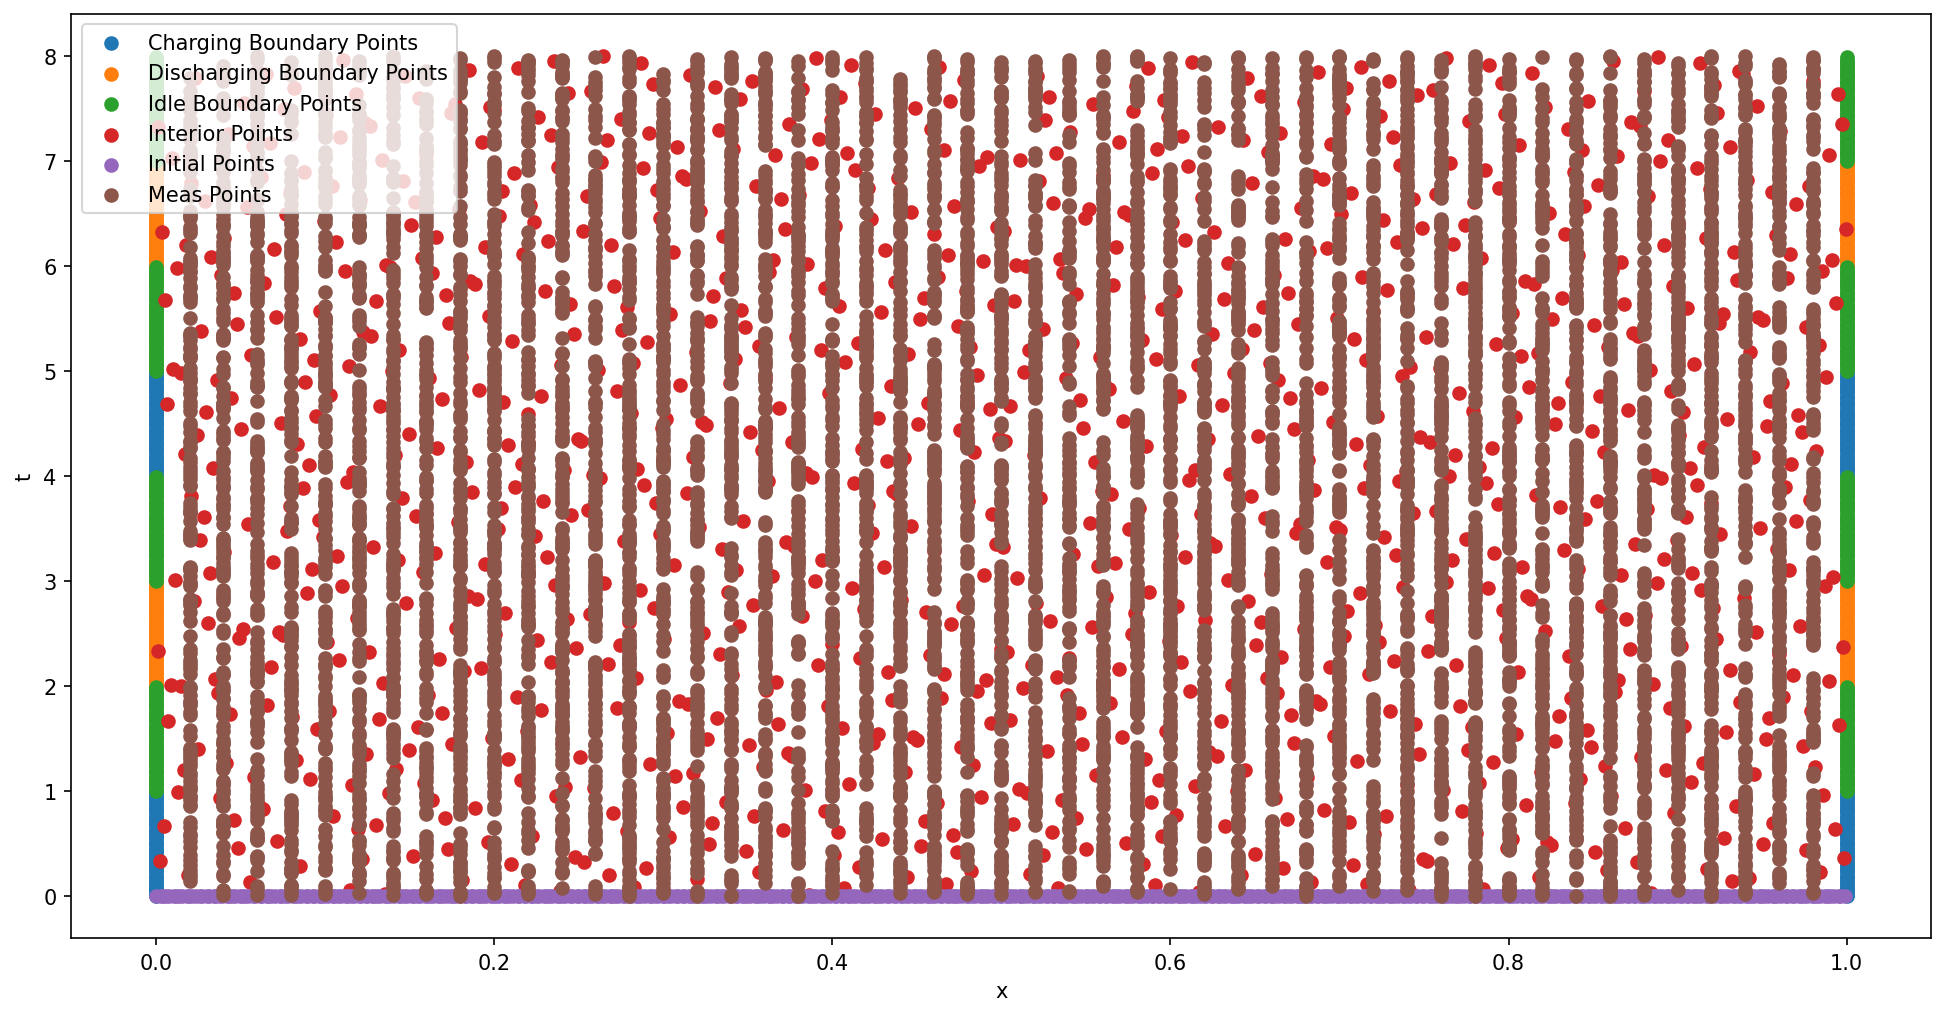

In [35]:
## Plot the input training points
input_sb_charging, output_sb_Tf_charging, input_sb_discharging, output_sb_Tf_discharging, input_sb_idle, output_sb_Tf_idl = pinn.add_spatial_boundary_points()
input_tb_,  output_tb_tf  = pinn.add_temporal_boundary_points()
input_int_, output_int_ = pinn.add_interior_points()
Input_meas, op_meas = next(iter(pinn.training_set_meas))

plt.figure(figsize=(16, 8), dpi=150)
plt.scatter(input_sb_charging[:, 1].detach().numpy(), input_sb_charging[:, 0].detach().numpy(), label="Charging Boundary Points")
plt.scatter(input_sb_discharging[:, 1].detach().numpy(), input_sb_discharging[:, 0].detach().numpy(), label="Discharging Boundary Points")
plt.scatter(input_sb_idle[:, 1].detach().numpy(), input_sb_idle[:, 0].detach().numpy(), label="Idle Boundary Points")
plt.scatter(input_int_[:, 1].detach().numpy(), input_int_[:, 0].detach().numpy(), label="Interior Points")
plt.scatter(input_tb_[:, 1].detach().numpy(), input_tb_[:, 0].detach().numpy(), label="Initial Points")
plt.scatter(Input_meas[:, 1].detach().numpy(), Input_meas[:, 0].detach().numpy(), label="Meas Points")
plt.xlabel("x")
plt.ylabel("t")
plt.legend()
plt.show()

In [36]:
n_epochs = 1000
optimizer_LBFGS = optim.LBFGS(pinn.approximate_solution.parameters(),
                              lr=float(0.5),
                              max_iter=5000,
                              max_eval=5000,
                              history_size=150,
                              line_search_fn="strong_wolfe",
                              tolerance_change=1.0 * np.finfo(float).eps)
optimizer_ADAM = optim.Adam(pinn.approximate_solution.parameters(),
                            lr=float(0.001))

################################  0  ################################
Total loss:  1.6656 | PDE Loss:  0.628 | Function Loss:  0.585
################################  1  ################################
Total loss:  1.6366 | PDE Loss:  0.6035 | Function Loss:  0.5022
################################  2  ################################
Total loss:  1.6132 | PDE Loss:  0.5837 | Function Loss:  0.4297
################################  3  ################################
Total loss:  1.5941 | PDE Loss:  0.5674 | Function Loss:  0.3696
################################  4  ################################
Total loss:  1.5778 | PDE Loss:  0.5531 | Function Loss:  0.3194
################################  5  ################################
Total loss:  1.5629 | PDE Loss:  0.54 | Function Loss:  0.2731
################################  6  ################################
Total loss:  1.5487 | PDE Loss:  0.5275 | Function Loss:  0.2274
################################  7  ######################

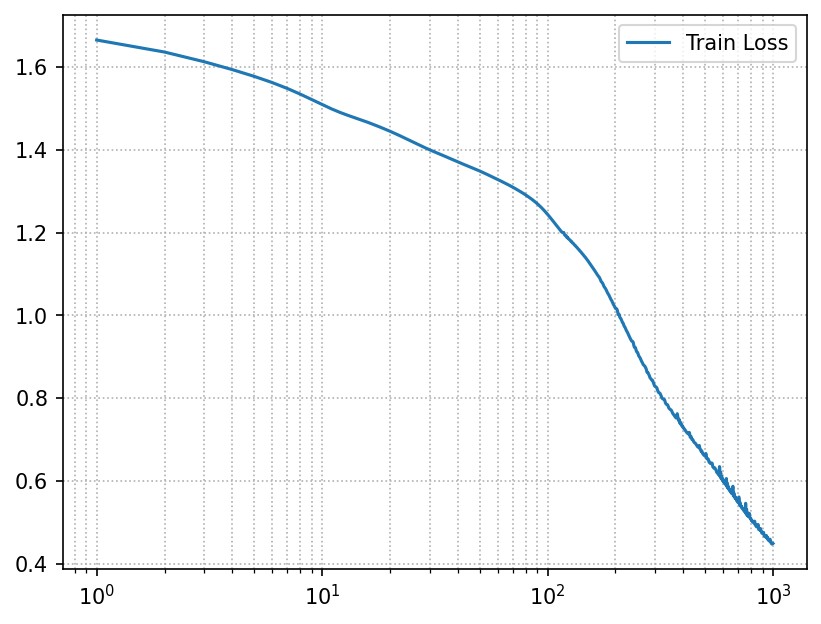

In [37]:
hist = pinn.fit(num_epochs=n_epochs,
                optimizer=optimizer_ADAM,
                verbose=True)

plt.figure(dpi=150)
plt.grid(True, which="both", ls=":")
plt.plot(np.arange(1, len(hist) + 1), hist, label="Train Loss")
plt.xscale("log")
plt.legend()

output.shape = torch.Size([100000, 2])


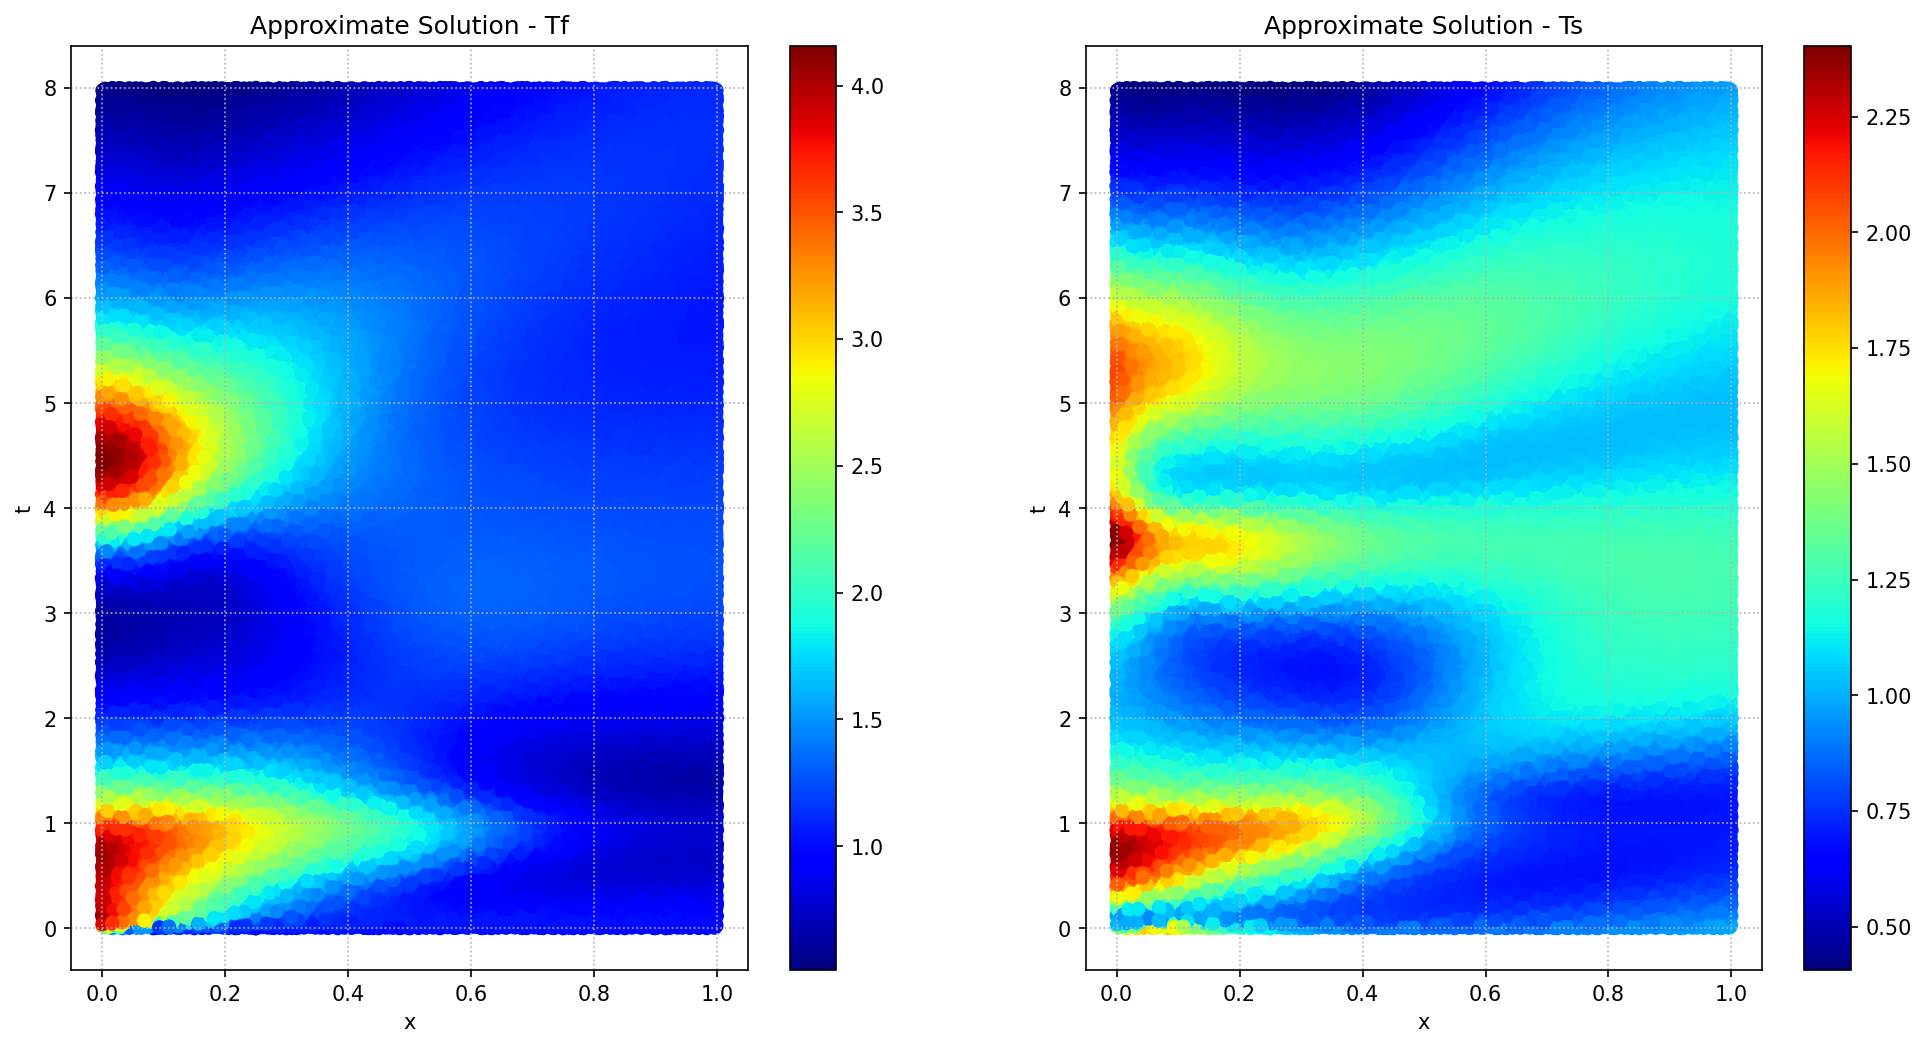

In [38]:
pinn.plotting()

In [40]:

input_test, _ = pinn.get_measurement_data()

output_test = pinn.approximate_solution(input_test)
op = torch.cat([input_test, output_test[:, 0].unsqueeze(1)], 1)
print(op.shape)


torch.Size([39200, 3])


In [41]:
op[:10]

tensor([[0.0000, 0.0200, 1.6974],
        [0.0100, 0.0200, 1.5245],
        [0.0200, 0.0200, 1.3466],
        [0.0300, 0.0200, 1.1955],
        [0.0401, 0.0200, 1.0799],
        [0.0501, 0.0200, 0.9968],
        [0.0601, 0.0200, 0.9401],
        [0.0701, 0.0200, 0.9041],
        [0.0801, 0.0200, 0.8849],
        [0.0901, 0.0200, 0.8792]], grad_fn=<SliceBackward0>)

In [42]:
store_path = r"TestingData_res.txt"

t_np = op.detach().numpy() #convert to Numpy array
df = pd.DataFrame(t_np) #convert to a dataframe
df.to_csv(store_path,index=False) #save to file

output.shape = torch.Size([39200, 2])


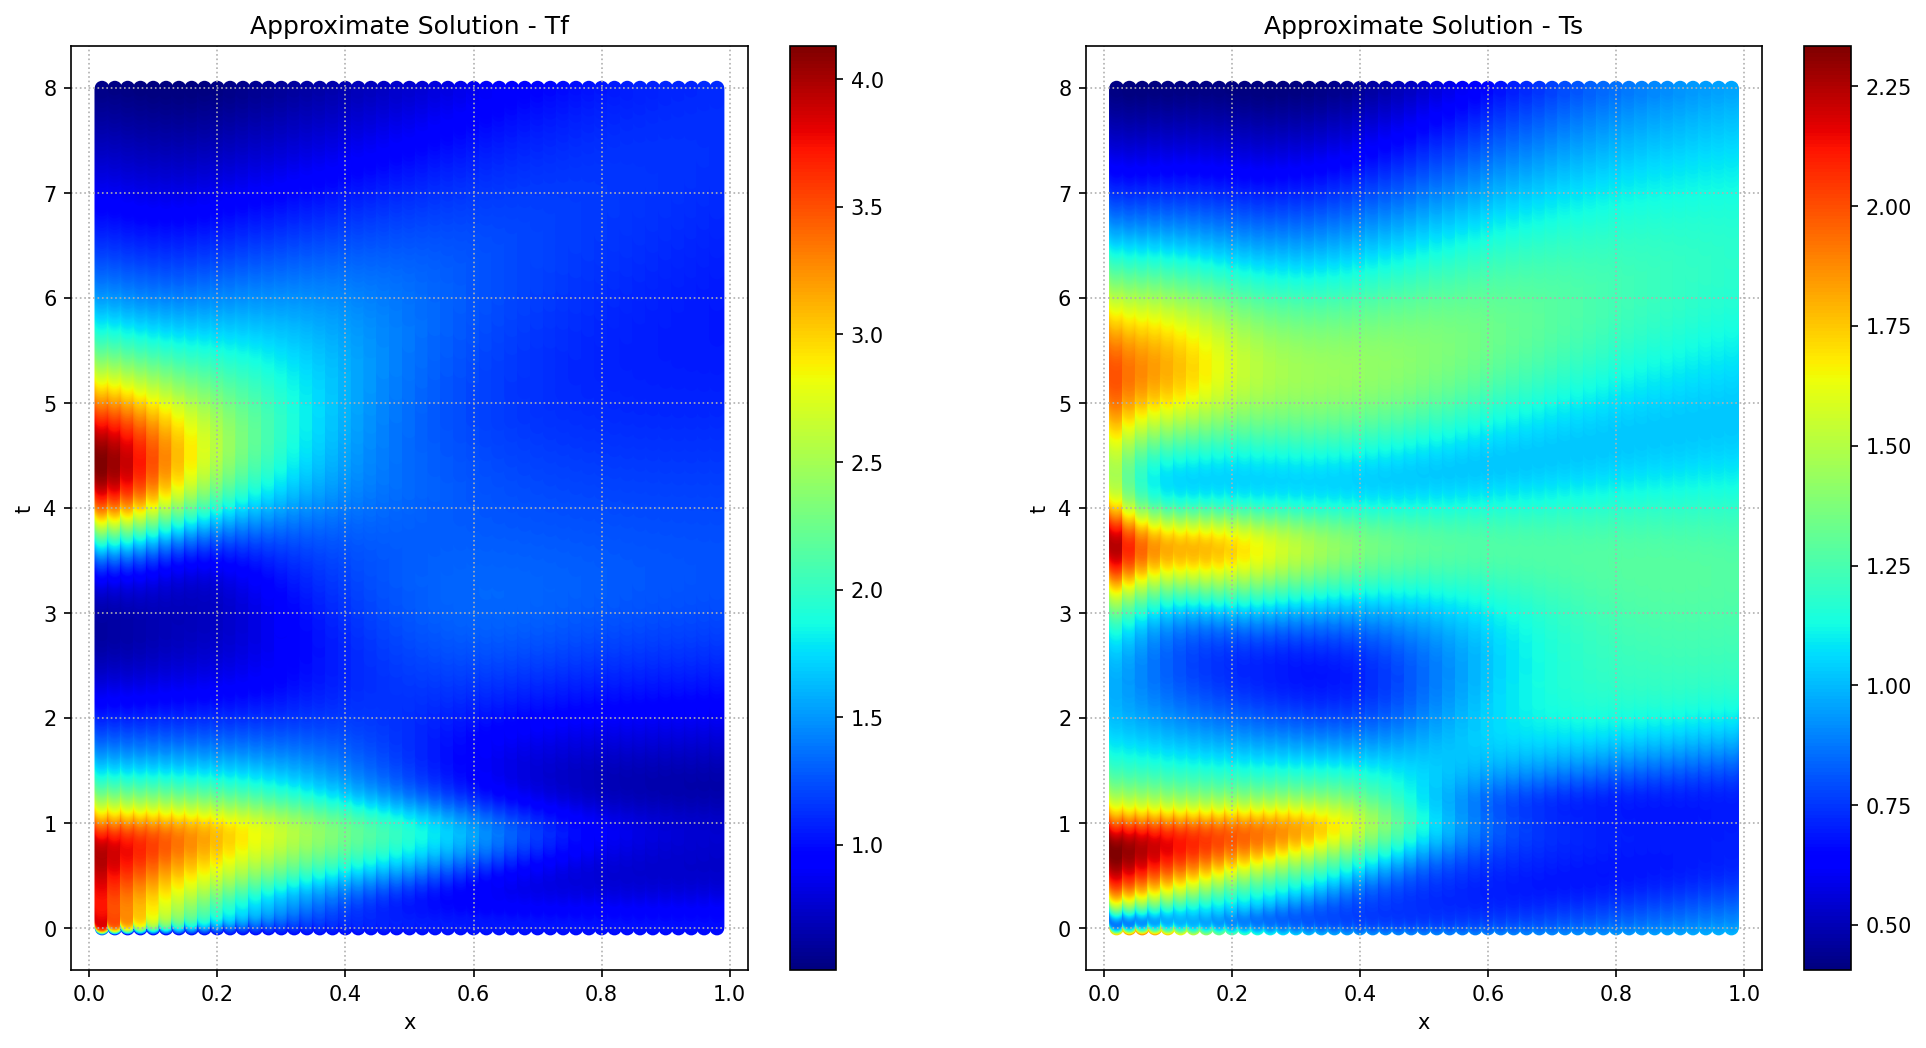

In [43]:
def plotting_test(inputs, output):

    print('output.shape = ' + str(output.shape))
    output_Ts = (output[:,0]).reshape(-1, )
    output_Tf = (output[:,1]).reshape(-1, )
    # exact_output = self.exact_solution(inputs).reshape(-1, )

    fig, axs = plt.subplots(1, 2, figsize=(16, 8), dpi=150)
    im1 = axs[0].scatter(inputs[:, 1].detach(), inputs[:, 0].detach(), c=output_Tf.detach(), cmap="jet")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("t")
    plt.colorbar(im1, ax=axs[0])
    axs[0].grid(True, which="both", ls=":")
    im2 = axs[1].scatter(inputs[:, 1].detach(), inputs[:, 0].detach(), c=output_Ts.detach(), cmap="jet")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("t")
    plt.colorbar(im2, ax=axs[1])
    axs[1].grid(True, which="both", ls=":")
    axs[0].set_title("Approximate Solution - Tf")
    axs[1].set_title("Approximate Solution - Ts")

    plt.show()

plotting_test(input_test, output_test)